# Analisis Aturan Asosiasi (Association Rule Mining) — Customer Shopping Dataset

Notebook ini melakukan analisis pola asosiasi (mirip *market basket analysis*) menggunakan **algoritma Apriori** pada dataset `customer_shopping_data.csv`.

**Catatan penting mengenai struktur data:** setiap baris pada dataset ini adalah satu invoice yang hanya berisi **satu kategori barang** (bukan banyak item per transaksi seperti pada data keranjang belanja supermarket). Karena itu, "transaksi" yang dianalisis di sini dibentuk dari kombinasi **atribut-atribut** pada setiap baris, yaitu:

- Gender pelanggan
- Kelompok usia
- Kategori barang yang dibeli
- Rentang harga
- Kelompok jumlah barang (quantity)
- Metode pembayaran
- Mal tempat belanja

Algoritma Apriori digunakan untuk menemukan kombinasi atribut yang sering muncul bersamaan (*frequent itemset*), lalu dari situ dibentuk aturan asosiasi berbentuk **JIKA (antecedent) MAKA (consequent)** beserta nilai *support*, *confidence*, dan *lift*-nya.

Algoritma Apriori pada notebook ini **diimplementasikan dari nol** (tanpa pustaka eksternal seperti `mlxtend`/`apyori`) agar setiap langkah pencarian *frequent itemset* dan pembentukan aturan dapat dipahami dengan jelas.

## 1. Import Library dan Memuat Dataset

In [1]:
# Upgrade pip terlebih dahulu
!python -m pip install --upgrade pip

# Install semua library yang dibutuhkan
!pip install pandas numpy matplotlib seaborn

print("Instalasi selesai! Silakan restart kernel.")

Defaulting to user installation because normal site-packages is not writeable
Defaulting to user installation because normal site-packages is not writeable
Instalasi selesai! Silakan restart kernel.


In [ ]:
# Jika instalasi berhasil, restart kernel agar library terdeteksi
# Klik menu Kernel -> Restart Kernel, atau jalankan kode di bawah:
import os
os._exit(00)  # Ini akan merestart kernel secara otomatis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations
import time

sns.set_style('whitegrid')
print("Semua library berhasil diimport!")
print("Versi pandas:", pd.__version__)

Semua library berhasil diimport!
Versi pandas: 3.0.3


In [2]:
df = pd.read_csv('customer_shopping_data.csv')
print('Ukuran data:', df.shape)
df.head()

Ukuran data: (99457, 10)


,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol AVM
4,I337046,C189076,Female,53,Books,4,60.60,Cash,24/10/2021,Kanyon


## 2. Eksplorasi Data Awal

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_no      99457 non-null  str    
 1   customer_id     99457 non-null  str    
 2   gender          99457 non-null  str    
 3   age             99457 non-null  int64  
 4   category        99457 non-null  str    
 5   quantity        99457 non-null  int64  
 6   price           99457 non-null  float64
 7   payment_method  99457 non-null  str    
 8   invoice_date    99457 non-null  str    
 9   shopping_mall   99457 non-null  str    
dtypes: float64(1), int64(2), str(7)
memory usage: 7.6 MB


In [4]:
print('Jumlah missing value per kolom:')
print(df.isna().sum())
print('\nJumlah baris duplikat:', df.duplicated().sum())

Jumlah missing value per kolom:
invoice_no        0
customer_id       0
gender            0
age               0
category          0
quantity          0
price             0
payment_method    0
invoice_date      0
shopping_mall     0
dtype: int64

Jumlah baris duplikat: 0


In [5]:
df.describe()

,age,quantity,price
count,99457.000000,99457.000000,99457.000000
mean,43.427089,3.003429,689.256321
std,14.990054,1.413025,941.184567
min,18.000000,1.000000,5.230000
25%,30.000000,2.000000,45.450000
50%,43.000000,3.000000,203.300000
75%,56.000000,4.000000,1200.320000
max,69.000000,5.000000,5250.000000


In [6]:
print(df['category'].value_counts())
print()
print(df['payment_method'].value_counts())
print()
print(df['shopping_mall'].value_counts())

category
Clothing           34487
Cosmetics          15097
Food & Beverage    14776
Toys               10087
Shoes              10034
Souvenir            4999
Technology          4996
Books               4981
Name: count, dtype: int64

payment_method
Cash           44447
Credit Card    34931
Debit Card     20079
Name: count, dtype: int64

shopping_mall
Mall of Istanbul     19943
Kanyon               19823
Metrocity            15011
Metropol AVM         10161
Istinye Park          9781
Zorlu Center          5075
Cevahir AVM           4991
Forum Istanbul        4947
Viaport Outlet        4914
Emaar Square Mall     4811
Name: count, dtype: int64


## 3. Pra-Pemrosesan: Mengubah Atribut Numerik Menjadi Kategori

Algoritma Apriori bekerja pada data **kategorikal** (bentuk item, bukan angka kontinu). Karena itu, atribut numerik berikut dikelompokkan (*binning*) menjadi kategori:

- **Usia (`age`)** → dikelompokkan menjadi 5 rentang usia.
- **Harga (`price`)** → dikelompokkan menjadi 3 rentang (Murah, Sedang, Mahal) menggunakan kuantil, sehingga jumlah data di tiap kelompok relatif seimbang.
- **Jumlah barang (`quantity`)** → dikelompokkan menjadi 3 kelompok (Sedikit, Sedang, Banyak).

In [7]:
# Usia -> 5 kelompok
age_bins = [17, 25, 35, 45, 55, 70]
age_labels = ['18-25', '26-35', '36-45', '46-55', '56-69']
df['age_group'] = pd.cut(df['age'], bins=age_bins, labels=age_labels)

# Harga -> 3 kelompok (Murah, Sedang, Mahal) menggunakan qcut
df['price_range'] = pd.qcut(df['price'], q=3, labels=['Murah', 'Sedang', 'Mahal'])

# Quantity -> 3 kelompok
qty_bins = [0, 1, 3, 5]
qty_labels = ['Sedikit (1)', 'Sedang (2-3)', 'Banyak (4-5)']
df['quantity_group'] = pd.cut(df['quantity'], bins=qty_bins, labels=qty_labels)

# Cek hasil
df[['age', 'age_group', 'price', 'price_range', 'quantity', 'quantity_group']].head(10)

,age,age_group,price,price_range,quantity,quantity_group
0,28,26-35,1500.40,Mahal,5,Banyak (4-5)
1,21,18-25,1800.51,Mahal,3,Sedang (2-3)
2,20,18-25,300.08,Sedang,1,Sedikit (1)
3,66,56-69,3000.85,Mahal,5,Banyak (4-5)
4,53,46-55,60.60,Murah,4,Banyak (4-5)
5,28,26-35,1500.40,Mahal,5,Banyak (4-5)
6,49,46-55,40.66,Murah,1,Sedikit (1)
7,32,26-35,600.16,Sedang,2,Sedang (2-3)
8,69,56-69,900.24,Sedang,3,Sedang (2-3)
9,60,56-69,600.16,Sedang,2,Sedang (2-3)


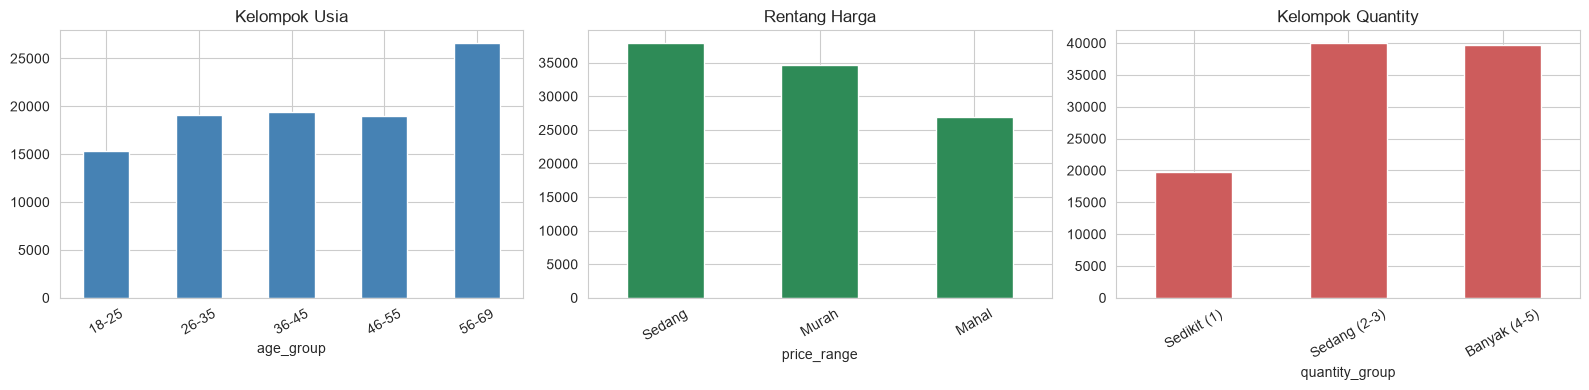

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
df['age_group'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue', title='Kelompok Usia')
df['price_range'].value_counts().plot(kind='bar', ax=axes[1], color='seagreen', title='Rentang Harga')
df['quantity_group'].value_counts().sort_index().plot(kind='bar', ax=axes[2], color='indianred', title='Kelompok Quantity')
for ax in axes:
    ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

## 4. Membentuk "Transaksi" untuk Analisis Asosiasi

Setiap baris data diubah menjadi sebuah **transaksi**: kumpulan *item* berbentuk `nama_atribut=nilai`. Satu invoice akan menjadi satu transaksi yang berisi 7 item (gender, kelompok usia, kategori, rentang harga, kelompok quantity, metode pembayaran, dan mal).

In [9]:
def row_to_items(row):
    return frozenset([
        f"Gender={row['gender']}",
        f"Usia={row['age_group']}",
        f"Kategori={row['category']}",
        f"Harga={row['price_range']}",
        f"Qty={row['quantity_group']}",
        f"Bayar={row['payment_method']}",
        f"Mall={row['shopping_mall']}",
    ])

transactions = df.apply(row_to_items, axis=1).tolist()
n_trans = len(transactions)

print(f'Jumlah transaksi: {n_trans}')
print(f'Contoh transaksi pertama:')
for item in sorted(transactions[0]):
    print(' -', item)

Jumlah transaksi: 99457
Contoh transaksi pertama:
 - Bayar=Credit Card
 - Gender=Female
 - Harga=Mahal
 - Kategori=Clothing
 - Mall=Kanyon
 - Qty=Banyak (4-5)
 - Usia=26-35


## 5. Algoritma Apriori — Implementasi Manual

Tiga metrik utama dalam analisis asosiasi:

- **Support**: $support(X) = \dfrac{\text{jumlah transaksi yang mengandung } X}{\text{total transaksi}}$ — seberapa sering itemset $X$ muncul.
- **Confidence**: $confidence(A \rightarrow B) = \dfrac{support(A \cup B)}{support(A)}$ — seberapa besar kemungkinan $B$ muncul jika $A$ sudah muncul.
- **Lift**: $lift(A \rightarrow B) = \dfrac{confidence(A \rightarrow B)}{support(B)}$ — seberapa kuat hubungan $A$ dan $B$ dibanding jika keduanya independen. Lift > 1 berarti asosiasi positif, lift ≈ 1 berarti hampir tidak ada hubungan, lift < 1 berarti asosiasi negatif.

Algoritma Apriori bekerja secara berjenjang (*level-wise*):

1. Hitung support semua item tunggal → ambil yang memenuhi `min_support` (disebut $L_1$).
2. Bentuk kandidat itemset berukuran-2 dari kombinasi $L_1$, hitung supportnya, ambil yang lolos `min_support` → $L_2$.
3. Ulangi untuk ukuran berikutnya. Prinsip Apriori: **subset dari itemset frequent juga pasti frequent**, sehingga kandidat yang memiliki subset tidak-frequent langsung dibuang (pruning) tanpa perlu dihitung — inilah yang membuat Apriori efisien.
4. Proses berhenti ketika tidak ada lagi itemset baru yang lolos `min_support`.

In [10]:
def get_frequent_1_itemsets(transactions, min_support_count):
    """Menghitung support semua item tunggal dan menyaring yang memenuhi min_support."""
    item_counts = {}
    for t in transactions:
        for item in t:
            key = frozenset([item])
            item_counts[key] = item_counts.get(key, 0) + 1
    return {item: c for item, c in item_counts.items() if c >= min_support_count}

In [11]:
def generate_candidates(prev_frequent_itemsets, k):
    """Membentuk kandidat itemset berukuran k dari itemset frequent berukuran (k-1),
    dengan pruning: kandidat dibuang jika ada subset berukuran (k-1) yang tidak frequent."""
    candidates = set()
    prev_keys = list(prev_frequent_itemsets.keys())
    for i in range(len(prev_keys)):
        for j in range(i + 1, len(prev_keys)):
            union = prev_keys[i] | prev_keys[j]
            if len(union) == k:
                subsets = combinations(union, k - 1)
                if all(frozenset(s) in prev_frequent_itemsets for s in subsets):
                    candidates.add(union)
    return candidates

In [12]:
def count_support(transactions, candidates):
    """Menghitung berapa kali setiap kandidat itemset muncul di seluruh transaksi."""
    counts = {c: 0 for c in candidates}
    for t in transactions:
        for c in candidates:
            if c.issubset(t):
                counts[c] += 1
    return counts

In [13]:
def run_apriori(transactions, n_trans, min_support, verbose=True):
    """Menjalankan algoritma Apriori secara penuh, mengembalikan seluruh frequent itemset
    (dalam bentuk dict {itemset(frozenset): jumlah_kemunculan})."""
    min_support_count = min_support * n_trans
    all_frequent = {}

    L1 = get_frequent_1_itemsets(transactions, min_support_count)
    all_frequent.update(L1)
    if verbose:
        print(f'Level 1: {len(L1)} itemset frequent')

    k = 2
    Lk_prev = L1
    while Lk_prev:
        candidates = generate_candidates(Lk_prev, k)
        if not candidates:
            break
        counts = count_support(transactions, candidates)
        Lk = {c: cnt for c, cnt in counts.items() if cnt >= min_support_count}
        if verbose:
            print(f'Level {k}: {len(candidates)} kandidat diuji -> {len(Lk)} itemset frequent')
        if not Lk:
            break
        all_frequent.update(Lk)
        Lk_prev = Lk
        k += 1

    return all_frequent

## 6. Menjalankan Algoritma Apriori

Parameter `MIN_SUPPORT` dapat diubah untuk mengeksplorasi lebih banyak/sedikit itemset. Nilai 0.05 berarti sebuah kombinasi atribut harus muncul pada minimal 5% dari seluruh transaksi untuk dianggap "sering".

In [14]:
MIN_SUPPORT = 0.05

start = time.time()
frequent_itemsets = run_apriori(transactions, n_trans, MIN_SUPPORT)
elapsed = time.time() - start

print(f'\nTotal itemset frequent yang ditemukan: {len(frequent_itemsets)}')
print(f'Waktu eksekusi: {elapsed:.2f} detik')

Level 1: 31 itemset frequent
Level 2: 465 kandidat diuji -> 159 itemset frequent
Level 3: 476 kandidat diuji -> 76 itemset frequent
Level 4: 25 kandidat diuji -> 9 itemset frequent

Total itemset frequent yang ditemukan: 275
Waktu eksekusi: 10.00 detik


## 7. Itemset yang Paling Sering Muncul

In [15]:
items_df = pd.DataFrame([
    {
        'itemset': ', '.join(sorted(k)),
        'jumlah_item': len(k),
        'support': v / n_trans,
        'jumlah_transaksi': v,
    }
    for k, v in frequent_itemsets.items()
]).sort_values('support', ascending=False).reset_index(drop=True)

items_df.head(15)

,itemset,jumlah_item,support,jumlah_transaksi
0,Gender=Female,1,0.598068,59482
1,Bayar=Cash,1,0.446897,44447
2,Qty=Sedang (2-3),1,0.401953,39977
3,Gender=Male,1,0.401932,39975
4,Qty=Banyak (4-5),1,0.399298,39713
5,Harga=Sedang,1,0.381150,37908
6,Bayar=Credit Card,1,0.351217,34931
7,Harga=Murah,1,0.348633,34674
8,Kategori=Clothing,1,0.346753,34487
9,Harga=Mahal,1,0.270217,26875


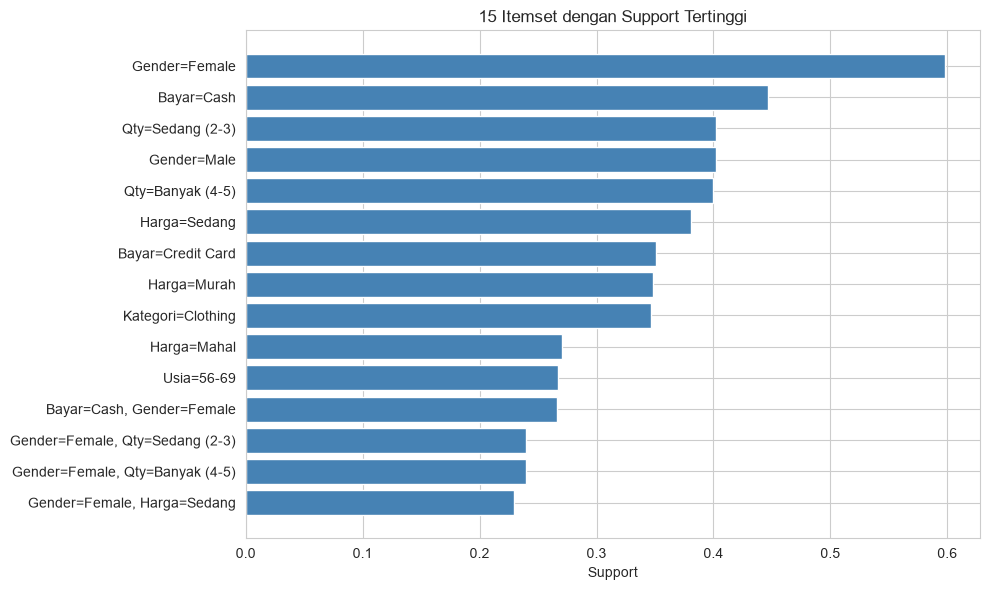

In [16]:
top15 = items_df.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(top15['itemset'], top15['support'], color='steelblue')
ax.set_xlabel('Support')
ax.set_title('15 Itemset dengan Support Tertinggi')
plt.tight_layout()
plt.show()

## 8. Pembentukan Aturan Asosiasi (Association Rules)

Dari setiap frequent itemset berukuran ≥ 2, dibentuk semua kemungkinan pembagian menjadi `antecedent` (A) dan `consequent` (B), lalu dihitung confidence dan lift-nya. Hanya aturan dengan confidence ≥ `MIN_CONFIDENCE` yang disimpan.

In [17]:
def generate_rules(all_frequent, n_trans, min_confidence):
    rules = []
    for itemset, support_count in all_frequent.items():
        if len(itemset) < 2:
            continue
        itemset_support = support_count / n_trans
        for i in range(1, len(itemset)):
            for antecedent in combinations(itemset, i):
                antecedent = frozenset(antecedent)
                consequent = itemset - antecedent
                if antecedent not in all_frequent or consequent not in all_frequent:
                    continue
                antecedent_support = all_frequent[antecedent] / n_trans
                consequent_support = all_frequent[consequent] / n_trans
                confidence = itemset_support / antecedent_support
                if confidence >= min_confidence:
                    lift = confidence / consequent_support
                    rules.append({
                        'antecedent': antecedent,
                        'consequent': consequent,
                        'support': itemset_support,
                        'confidence': confidence,
                        'lift': lift,
                    })
    return rules

In [18]:
MIN_CONFIDENCE = 0.6

rules = generate_rules(frequent_itemsets, n_trans, MIN_CONFIDENCE)
print(f'Total aturan asosiasi yang ditemukan (confidence >= {MIN_CONFIDENCE}): {len(rules)}')

rules_df = pd.DataFrame(rules)
rules_df['antecedent_str'] = rules_df['antecedent'].apply(lambda x: ' & '.join(sorted(x)))
rules_df['consequent_str'] = rules_df['consequent'].apply(lambda x: ' & '.join(sorted(x)))
rules_df = rules_df.sort_values('lift', ascending=False).reset_index(drop=True)

rules_df[['antecedent_str', 'consequent_str', 'support', 'confidence', 'lift']].head(20)

Total aturan asosiasi yang ditemukan (confidence >= 0.6): 76


,antecedent_str,consequent_str,support,confidence,lift
0,Harga=Murah & Qty=Banyak (4-5),Kategori=Food & Beverage,0.059051,0.600818,4.044098
1,Kategori=Technology,Harga=Mahal,0.050233,1.000000,3.700726
2,Kategori=Clothing & Qty=Banyak (4-5),Harga=Mahal,0.138643,1.000000,3.700726
3,Bayar=Cash & Kategori=Clothing & Qty=Banyak (4-5),Harga=Mahal,0.062238,1.000000,3.700726
4,Gender=Female & Kategori=Clothing & Qty=Banyak...,Harga=Mahal,0.083061,1.000000,3.700726
5,Gender=Male & Kategori=Clothing & Qty=Banyak (...,Harga=Mahal,0.055582,1.000000,3.700726
6,Kategori=Shoes,Harga=Mahal,0.081342,0.806259,2.983742
7,Kategori=Food & Beverage & Qty=Sedang (2-3),Harga=Murah,0.059332,1.000000,2.868345
8,Kategori=Books,Harga=Murah,0.050082,1.000000,2.868345
9,Gender=Female & Kategori=Food & Beverage,Harga=Murah,0.088521,1.000000,2.868345


## 9. Visualisasi Aturan Asosiasi

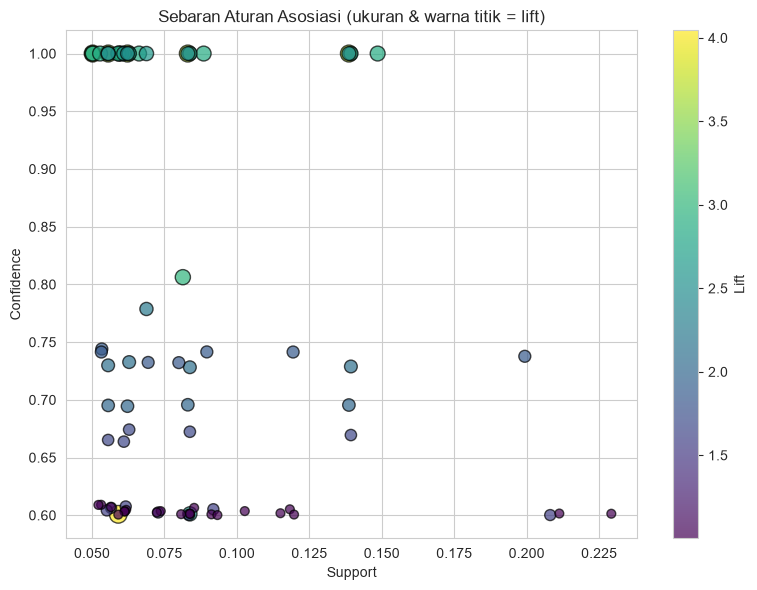

In [19]:
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(
    rules_df['support'], rules_df['confidence'],
    s=rules_df['lift'] * 40, c=rules_df['lift'], cmap='viridis', alpha=0.7, edgecolor='k'
)
ax.set_xlabel('Support')
ax.set_ylabel('Confidence')
ax.set_title('Sebaran Aturan Asosiasi (ukuran & warna titik = lift)')
plt.colorbar(scatter, label='Lift')
plt.tight_layout()
plt.show()

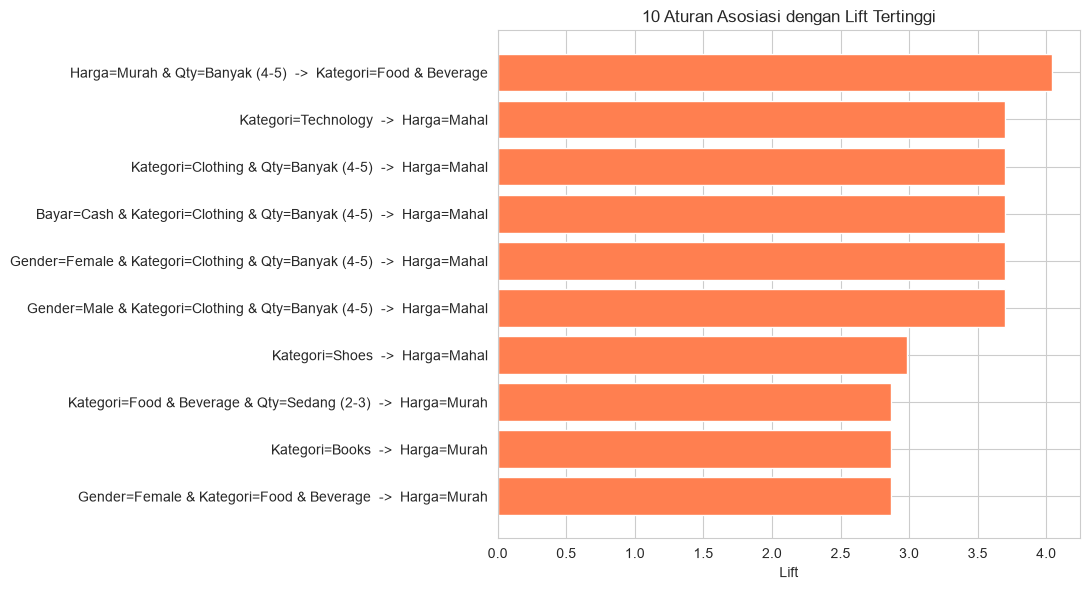

In [20]:
top10 = rules_df.head(10).iloc[::-1]
labels = [f"{a}  ->  {c}" for a, c in zip(top10['antecedent_str'], top10['consequent_str'])]

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(labels, top10['lift'], color='coral')
ax.set_xlabel('Lift')
ax.set_title('10 Aturan Asosiasi dengan Lift Tertinggi')
plt.tight_layout()
plt.show()

## 10. Insight Tambahan: Pola di Luar Hubungan Kategori–Harga

Banyak aturan dengan lift tertinggi pada dasarnya hanya menangkap hubungan antara `Kategori` dan `Harga` — hal yang cukup wajar karena tiap kategori barang memang punya rentang harga khasnya sendiri (misalnya Technology cenderung mahal, Books/Food & Beverage cenderung murah). Untuk melihat apakah ada pola yang lebih menarik di luar hubungan tersebut, aturan yang melibatkan atribut `Harga` difilter (disembunyikan), sehingga tersisa aturan antara atribut Gender, Usia, Kategori, Quantity, Metode Pembayaran, dan Mal.

In [21]:
mask_no_harga = ~(
    rules_df['antecedent_str'].str.contains('Harga') |
    rules_df['consequent_str'].str.contains('Harga')
)
rules_no_harga = rules_df[mask_no_harga].sort_values('lift', ascending=False)

print(f'Jumlah aturan tanpa atribut Harga: {len(rules_no_harga)}')
rules_no_harga[['antecedent_str', 'consequent_str', 'support', 'confidence', 'lift']].head(10)

Jumlah aturan tanpa atribut Harga: 12


,antecedent_str,consequent_str,support,confidence,lift
55,Bayar=Cash & Usia=36-45,Gender=Female,0.053149,0.609056,1.018374
58,Bayar=Credit Card & Qty=Banyak (4-5),Gender=Female,0.085233,0.606410,1.013948
59,Usia=36-45,Gender=Female,0.118262,0.605166,1.011869
60,Mall=Metropol AVM,Gender=Female,0.061775,0.604665,1.011031
64,Kategori=Toys,Gender=Female,0.061182,0.603252,1.008668
65,Bayar=Cash & Usia=56-69,Gender=Female,0.072353,0.602428,1.007291
67,Bayar=Credit Card,Gender=Female,0.211257,0.601500,1.005739
70,Kategori=Clothing & Qty=Sedang (2-3),Gender=Female,0.083765,0.601212,1.005258
72,Kategori=Cosmetics,Gender=Female,0.091195,0.600782,1.004538
73,Mall=Kanyon,Gender=Female,0.119710,0.600615,1.004260


## 11. Kesimpulan

Berdasarkan analisis aturan asosiasi pada dataset `customer_shopping_data.csv` dengan `MIN_SUPPORT = 0.05` dan `MIN_CONFIDENCE = 0.6`:

1. Aturan dengan **lift tertinggi** hampir semuanya menghubungkan **Kategori barang** dengan **Rentang Harga** dan **Quantity** (misalnya `Kategori=Technology -> Harga=Mahal` dengan lift sekitar 3.7, atau `Kategori=Clothing, Qty=Banyak (4-5) -> Harga=Mahal`). Pola ini cukup logis karena harga barang memang sangat dipengaruhi oleh kategorinya, bukan temuan yang mengejutkan, namun memperkuat validitas hasil analisis.
2. Setelah hubungan Kategori–Harga disisihkan, aturan yang melibatkan **Gender, Usia, Metode Pembayaran, dan Mal** memiliki nilai **lift yang sangat mendekati 1** (sekitar 1.0–1.02). Ini mengindikasikan bahwa pada data ini, pemilihan kategori belanja, metode pembayaran, dan mal **tidak menunjukkan asosiasi yang kuat** dengan gender maupun kelompok usia pelanggan — pola belanja relatif merata di semua segmen demografis.
3. Itemset tunggal yang paling sering muncul adalah `Gender=Female` (≈59.8% transaksi), `Bayar=Cash` (≈44.7%), dan `Kategori=Clothing` (≈34.7%), sejalan dengan hasil eksplorasi data di awal notebook.

**Saran pengembangan lebih lanjut:** nilai `MIN_SUPPORT` dan `MIN_CONFIDENCE` dapat diturunkan untuk menemukan lebih banyak aturan dengan dukungan data yang lebih kecil, atau atribut transaksi dapat ditambah/dikurangi (misalnya memecah `invoice_date` menjadi bulan/musim) untuk mengeksplorasi pola musiman dalam pembelian.